#### 환경 설정

In [2]:
import os

ROOT_DIR = os.getcwd()

# 코랩 모드
if ROOT_DIR == "/content":
    print("[[ colab ]]")
    
    import unicodedata
    
    DATA_DIR = os.path.join(ROOT_DIR, "data")
    TEXT_DIR = os.path.join(ROOT_DIR, "raw")

    if "raw.tar.gz" not in os.listdir():
        !wget https://github.com/wonbywondev/ML-DL/releases/download/data-v3/raw.tar.gz
    else:
        print("· raw.tar.gz (O)")


    if not os.path.exists(TEXT_DIR):
        !tar -xzvf raw.tar.gz -C /content
    else:
        print("· data (O)")


    if not os.path.exists(DATA_DIR):
        os.mkdir(DATA_DIR)


    train_json_path = os.path.join(TEXT_DIR, "일상생활및구어체_한영_train_set.json")
    val_json_path = os.path.join(TEXT_DIR, "일상생활및구어체_한영_valid_set.json")

    train_json_path = unicodedata.normalize("NFC", train_json_path)
    val_json_path = unicodedata.normalize("NFC", val_json_path)

# 로컬 모드
else:
    print("[[ local ]]")
    
    DATA_DIR = os.path.join(ROOT_DIR, "data")

    train_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_train_set.json")
    val_json_path = os.path.join(DATA_DIR, "raw", "일상생활및구어체_한영_valid_set.json")

[[ local ]]


In [3]:
# 기타 환경 설정
import torch
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import gc


# 시각화 관련 설정
try:
    plt.rcParams['font.family'] = 'Apple SD Gothic Neo'
except:
    try:
        plt.rcParams['font.family'] = 'NanumGothic'
    except:
        plt.rcParams['font.family'] = 'AppleGothic'

plt.rcParams['axes.unicode_minus'] = False
fm._load_fontmanager(try_read_cache=False)


# 디바이스 설정
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    DEVICE = torch.device("mps") # 맥 GPU
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda") # 윈도우 GPU
else:
    DEVICE = torch.device("cpu") # CPU


# 캐시 지우기 함수 생성
def clean_cache():
    gc.collect()
    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()


# MallocStackLogging 에러 출력 방지
os.environ.pop("MallocStackLogging", None)
os.environ.pop("MallocStackLoggingNoCompact", None)
os.environ.pop("DYLD_INSERT_LIBRARIES", None)


Matplotlib is building the font cache; this may take a moment.


---

# 목표

번역기 만들기

In [4]:
import json

with open(train_json_path, "r", encoding="utf-8") as f:
    train_data = json.load(f)

train_data = train_data["data"]

### 샘플 출력

In [5]:
import random

rand_idx = random.randint(1, len(train_data)) - 1

train_data[rand_idx]

{'sn': 'KPUS062012215092494',
 'data_set': '일상생활및구어체',
 'domain': '일상생활',
 'subdomain': '구매',
 'ko_original': '>뿌이 뿌이 뿌이 뿌이~',
 'ko': '>뿌이 뿌이 뿌이 뿌이~',
 'mt': '> Ppoi Ppoi Ppoi Ppoi Ppoi ppui~',
 'en': '> Ppuing ppuing ppuing ppuing~',
 'source_language': 'ko',
 'target_language': 'en',
 'word_count_ko': 4,
 'word_count_en': 5,
 'word_ratio': 1.25,
 'file_name': '구매_KPUS.xlsx',
 'source': 'SBS',
 'license': 'open',
 'style': '구어체',
 'included_unknown_words': False,
 'ner': None}

ner은 Named Entity Recognition. 꼭 살려둬야 한다.

In [6]:
print("[데이터 속성 고유값]")

unique_dict = {key: (set() if key != "ner" else list()) for key in train_data[0].keys()}

for i, dict_ in enumerate(train_data):   
    for key, value in dict_.items():
        if key == "ner":
            unique_dict[key].append(value if value else "null")
        else:
            unique_dict[key].add(value if value else "null")


for key, value in unique_dict.items():
    print(f"· {key}: {len(value)}개")

    if len(value) < 20:
        print(f"    - {value}")

[데이터 속성 고유값]
· sn: 1200000개
· data_set: 1개
    - {'일상생활및구어체'}
· domain: 3개
    - {'해외영업', '일상생활', '해외고객과의채팅'}
· subdomain: 11개
    - {'예약', '음식', '숙박,음식점', '부동산', '금융,보험', '기계장비,의료정밀', '도소매유통', '연구개발,과학기술', '구매', '여행', '정보통신'}
· ko_original: 1059799개
· ko: 1059798개
· mt: 1015045개
· en: 1024329개
· source_language: 1개
    - {'ko'}
· target_language: 1개
    - {'en'}
· word_count_ko: 56개
· word_count_en: 73개
· word_ratio: 673개
· file_name: 18개
    - {'CUSCHA_FNIN.xlsx', 'CUSCHA_MCHO.xlsx', 'INTSAL_STRS.xlsx', 'INTSAL_FNIN.xlsx', 'INTSAL_EGKG.xlsx', 'CUSCHA_STRS.xlsx', '음식_KFDS.xlsx', 'CUSCHA_DSUT.xlsx', 'INTSAL_MCHO.xlsx', '예약_KRSS.xlsx', 'CUSCHA_RLST.xlsx', '구매_KPUS.xlsx', 'CUSCHA_EGKG.xlsx', 'INTSAL_JBTS.xlsx', '여행_KTOS.xlsx', 'INTSAL_RLST.xlsx', 'CUSCHA_JBTS.xlsx', 'INTSAL_DSUT.xlsx'}
· source: 2개
    - {'크라우드소싱', 'SBS'}
· license: 1개
    - {'open'}
· style: 1개
    - {'구어체'}
· included_unknown_words: 1개
    - {'null'}
· ner: 1200000개


### 중복치

domain, subdomain, 내용이 일치하는 데이터를 언어별로 삭제.

번역본끼리 한 쌍, 원본끼리 한 쌍으로 묶는다.

In [7]:
import pandas as pd

useless_list = [
    "sn", "data_set", "license", "source", "style", 
    "included_unknown_words", "file_name", 
    "source_language", "target_language"
    ]

useful_list = [column for column in list(train_data[0].keys()) if column not in useless_list]

train_df = pd.DataFrame(train_data, columns=useful_list)

In [8]:
lang_list = [["ko_original", "en"], ["ko", "mt"]]

for lang in lang_list:
    train_df = train_df.drop_duplicates(["domain", "subdomain"] + lang, keep="first")

print(f"· 중복 제거 후 데이터: {len(train_df)}개")

· 중복 제거 후 데이터: 1080887개


### 극단치

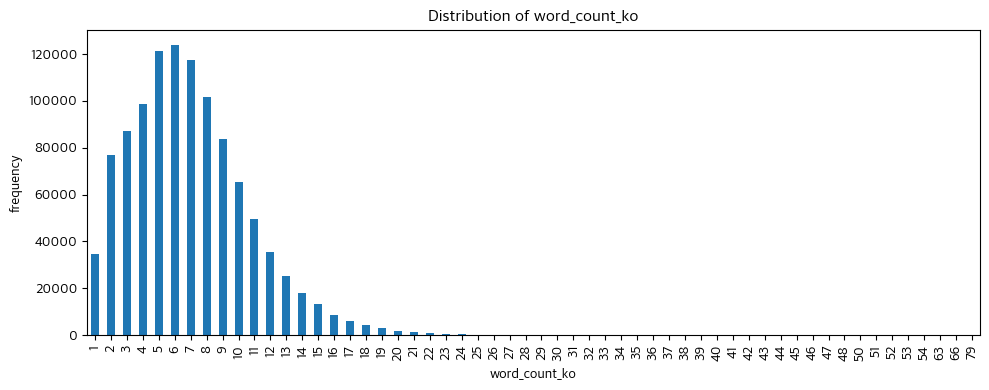

In [9]:
# word_count_ko
counts = train_df["word_count_ko"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_ko")
plt.ylabel("frequency")
plt.title("Distribution of word_count_ko")
plt.tight_layout()
plt.show()

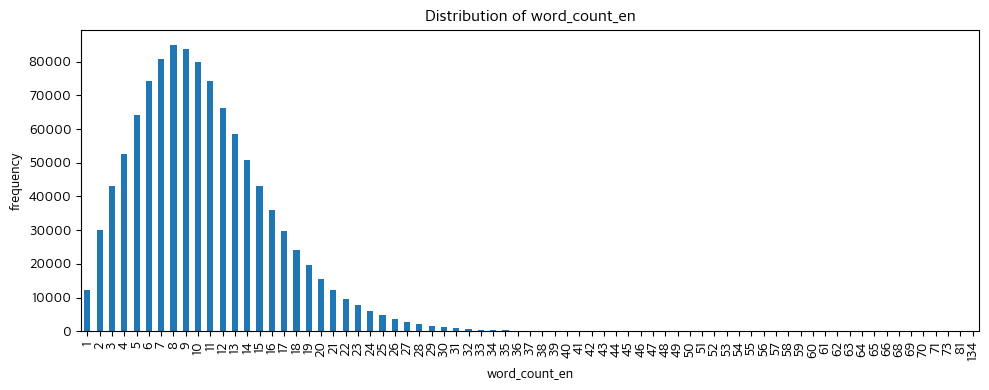

In [10]:
# word_count_en
counts = train_df["word_count_en"].value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_count_en")
plt.ylabel("frequency")
plt.title("Distribution of word_count_en")
plt.tight_layout()
plt.show()

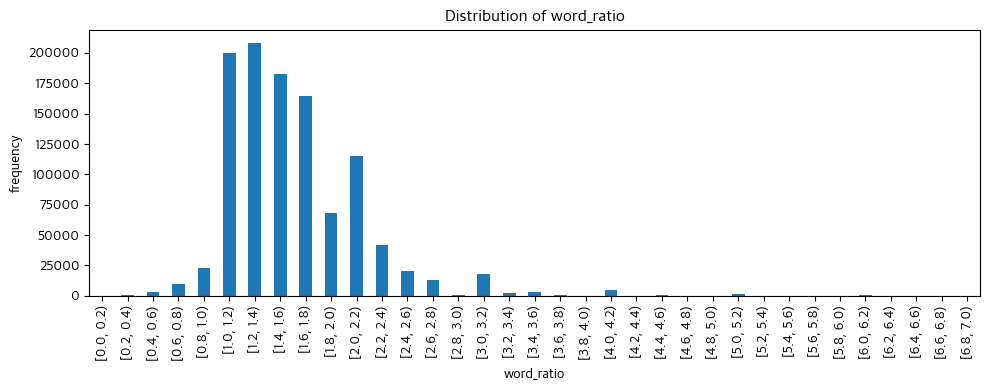

In [11]:
# word_ratio
import numpy as np

bins = np.arange(0, 7.2, 0.2)
groups = pd.cut(train_df["word_ratio"], bins=bins, right=False)

counts = groups.value_counts().sort_index()

plt.figure(figsize=(10,4))
counts.plot(kind="bar")
plt.xlabel("word_ratio")
plt.ylabel("frequency")
plt.title("Distribution of word_ratio")
plt.tight_layout()

plt.show()

In [12]:
train_df = train_df[train_df["word_count_ko"] <= 25]
train_df = train_df[train_df["word_count_en"] <= 35]
train_df = train_df[train_df["word_ratio"] <= 3.5]

### 도메인 맵핑

In [13]:
DOMAIN_KEY_MAP = {value: i for i, value in enumerate(unique_dict["domain"])}
SUBDOMAIN_KEY_MAP = {value: i for i, value in enumerate(unique_dict["subdomain"])}

DOMAIN_NUM_MAP = {i:value for i, value in enumerate(unique_dict["domain"])}
SUBDOMAIN_NUM_MAP = {i:value for i, value in enumerate(unique_dict["subdomain"])}

train_df["domain"] = train_df['domain'].map(DOMAIN_KEY_MAP)
train_df["subdomain"] = train_df['subdomain'].map(SUBDOMAIN_KEY_MAP)

In [14]:
train_df = train_df.reset_index().drop("index", axis=1)

In [15]:
TRAIN_DICT = train_df.to_dict("index")
print(f"· 가공 후 데이터: {len(TRAIN_DICT)}개")

· 가공 후 데이터: 1070866개


In [16]:
rand_idx = random.randint(1, len(TRAIN_DICT)) - 1

print("[가공 후 샘플 출력]")
print(f"key: {rand_idx}")
TRAIN_DICT[rand_idx]

[가공 후 샘플 출력]
key: 257242


{'domain': 1,
 'subdomain': 0,
 'ko_original': '>아이고, 아이고, 아이고.',
 'ko': '>아이고, 아이고, 아이고.',
 'mt': '> Oh my, oh my, oh my.',
 'en': '>Oh my, oh my, oh my.',
 'word_count_ko': 3,
 'word_count_en': 6,
 'word_ratio': 2.0,
 'ner': None}

# 실험 계획

1. ner 데이터를 이용하여 다른 데이터에도 적용한다.

In [17]:
ner_dict = dict()

for key, value in TRAIN_DICT.items():
    if value["ner"]:
        ner_dict[key] = value["ner"]

In [18]:
unique_ner_tag_set = set()

for key, value in ner_dict.items():
    for tag_dict in value["tags"]:
        unique_ner_tag_set.add(tag_dict["tag"])

unique_ner_tag_set

{'ORG', 'PERSON', 'PRODUCT', 'WORK_OF_ART'}

In [ ]:
import re

ner_tag_err_dict = dict()
ner_count_err_dict = dict()

for key, value in ner_dict.items():
    text = value["text"]
    tag_list = value["tags"]
    
    tag_count = len(tag_list)
    tag_pattern = re.compile(r"<(?P<tag>[A-Z][A-Z0-9_]*)>(.*?)</(?P=tag)>", re.DOTALL)
    actual_tag_count = sum(1 for _ in tag_pattern.finditer(text))

    if tag_count < actual_tag_count:
        ner_count_err_dict[key] = value

    err_tag_list = list()

    for tag_dict in tag_list:
        tag = tag_dict["tag"]
        text_value = tag_dict["value"]

        pattern = rf"<{re.escape(tag)}>{re.escape(text_value)}</{re.escape(tag)}>"
        if not re.search(pattern, text):
            err_tag_list.append(tag_dict)

    if err_tag_list:
        ner_tag_err_dict[key] = {
            "text": text,
            "tags": err_tag_list
            }
        
print("[NER 오류]")
print(f"· 표기 오류: {len(ner_tag_err_dict)}개")
print(f"· 누락 오류: {len(ner_count_err_dict)}개")

[NER 오류]
· 표기 오류: 260개
· 누락 오류: 0개


In [ ]:
## TODO: 위치 기반까지 에러 추적하기
ner_position_err_dict = dict()

for key, value in ner_dict.items():
    text = value["text"]
    tag_list = value["tags"]

    if len(tag_list) > 1:
        continue

    err_tag_list = list()

    for tag_dict in tag_list:
        tag = tag_dict["tag"]
        text_value = tag_dict["value"]
        
        pattern = f"<{tag}>{text_value}</{tag}>"

        try: 
            position = tag_dict["position"]
            start_position = int(position.strip("[").split(",")[0])
        
            if text[start_position: start_position + len(pattern)] != pattern:
                err_tag_list.append(tag_dict)
        except:
            err_tag_list.append(tag_dict)


    if err_tag_list:
        ner_position_err_dict[key] = {
            "text": text,
            "tags": err_tag_list
            }

print("[NER 오류]")
print(f"· 오류: {len(ner_position_err_dict)}개")

ner_position_err_dict


[NER 오류]
· 오류: 134개


{3541: {'text': '저는<PRODUCT> 커피 탬퍼</PRODUCT> 제품을 소개하려고 합니다.',
  'tags': [{'tag': 'PRODUCT', 'value': '커피 탬퍼', 'position': '[2, 8]'}]},
 14292: {'text': '공식 라이선스 키패드, 마우스 컨트롤러는<PRODUCT> PS4</PRODUCT>에 PC 스타일의 제어를 제공합니다.',
  'tags': [{'tag': 'PRODUCT', 'value': 'PS4', 'position': '[22, 26]'}]},
 15718: {'text': '> <PERSON>은혁이 </PERSON>스파이 아닐거에요.',
  'tags': [{'tag': 'PERSON', 'value': '은혁이', 'position': '[2, 6]'}]},
 17541: {'text': '저는 지난 5년간 <ORG>BBB </ORG>회사의 회계 부서에서 재무 관리를 담당해왔습니다.',
  'tags': [{'tag': 'ORG', 'value': 'BBB', 'position': '[10, 14]'}]},
 20516: {'text': '친애하는<PERSON> Jupiter</PERSON>님, 어제 저희 단골 고객과의 만남에서 귀하의 회사를 알게 되었습니다.',
  'tags': [{'tag': 'PERSON', 'value': 'Jupiter', 'position': '[4, 12]'}]},
 30537: {'text': '사실<ORG> V 디자인</ORG>은 오랜 세월 동안 가장 힘든 작업 현장에서 중요한 역할을 해왔습니다.',
  'tags': [{'tag': 'ORG', 'value': 'V 디자인', 'position': '[2, 8]'}]},
 33024: {'text': '>아, 그러니까 나는 내가 보기에는 <PERSON>민석이 </PERSON>되게 착하단 말이야.',
  'tags': [{'tag': 'PERSON', 'value': '민석이', 'position'

In [26]:
ner_err_json_path = os.path.join(DATA_DIR, "ner_err.json")

with open(ner_err_json_path, "w", encoding="utf-8") as f:
    json.dump(ner_tag_err_dict, f, indent=4, ensure_ascii=False)